### Trading Causes Exponential Distribution of Wealth.

from:
<br> - https://www.youtube.com/watch?v=NusYLzb-Uho&t=350s
<br> - http://physics.umd.edu/~yakovenk/econophysics/animation.html
<br>
<br>At the beginning everyone has $10, and graph is a delta function.
<br>When trading starts, the graph spreads into normal distribution.
<br>Then it spreads more, eventually into exponential distribution.
<br>
<br>Two tips about of this notebook:
<br> - same graph is being refreshed using ```clear_output(wait=True)```
<br> - if you stop the execution by interrupting the kernel, it stops gracefully without the red error trace

In [1]:
import os, sys, time, random
from IPython.display import clear_output
from matplotlib import pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
def mygraph(vals, trades=0, stat_str = ""):
    clear_output(wait=True)
    plt.figure(figsize=(8,3))
    plt.hist(vals, bins=200, range=(0,200))
    trades_str = "{:,}".format(trades)
    mytitle = "Distribution of Wealth after %s trades. " % trades_str
    if len(stat_str) <=0 :
        stat_str = "\nPress stop button (square) to stop execution."
    plt.title(mytitle + stat_str)
    plt.grid(True)
    plt.show();

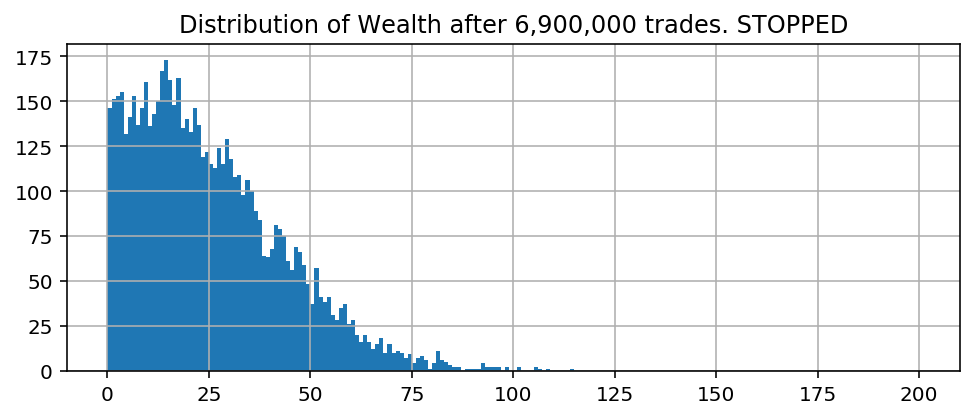

In [3]:
data = {}
N = 10000
N1= N-1
vals = [10]*N
N_trades = 100000
try:
    for i in range(10**7):
        mygraph(vals, trades=i*N_trades)
        i += 1
        for j in range(N_trades):
            i1 = random.randint(0,N1)
            i2 = random.randint(0,N1)
            while (i2 == i1):
                i2 = random.randint(0,N1)
            # ---------
            loss_n = random.randint(0,1)
            # remove cases when a person can not trade down
            if (loss_n==0 * vals[i1] == 0) or (loss_n==1 * vals[i2] == 0):
                continue
            # trade:
            if loss_n == 0:   # i1 has lost
                vals[i1] -= 1 # loss
                vals[i2] += 1 # gain
            else:
                vals[i1] += 1 # gain
                vals[i2] -= 1 # loss

except KeyboardInterrupt:
    mygraph(vals, trades=(i+1)*N_trades, stat_str="STOPPED")